In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Load data
data = pd.read_csv("../datasets/mimic3d.csv")

# 1. Drop sensitive columns and identifiers
data_clean = data.drop(columns=
                       ['hadm_id', 'LOSdays', 'religion', 'marital_status', 'ethnicity'])

# 2. Separate features and target
X = data_clean.drop(columns=['LOSgroupNum'])
y = data_clean['LOSgroupNum']

# Define LOS groups (adjust thresholds as needed)
def map_los_group(los_days):
    if los_days < 3:
        return 0  # Short Stay
    elif 3 <= los_days < 7:
        return 1  # Medium Stay
    else:
        return 2  # Long Stay

# Apply mapping (if LOSdays is available)
data['LOSgroupNum'] = data['LOSdays'].apply(map_los_group)

# Verify the mapping
print(data[['LOSdays', 'LOSgroupNum']].head())
# 3. Handle missing values (using SimpleImputer directly)
imputer = SimpleImputer(strategy='constant', fill_value='Missing')
categorical_cols = ['gender', 'admit_type', 'admit_location', 
                   'AdmitDiagnosis', 'insurance', 'AdmitProcedure']
X[categorical_cols] = imputer.fit_transform(X[categorical_cols])

# 4. Label Encoding for categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le  # Store encoders for future use if needed

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train RandomForest
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 7. Evaluate
print(f"Train Accuracy: {model.score(X_train, y_train):.2f}")
print(f"Test Accuracy: {model.score(X_test, y_test):.2f}")

   LOSdays  LOSgroupNum
0     6.17            1
1     4.04            1
2    12.04            2
3     7.29            2
4     4.88            1
Train Accuracy: 0.94
Test Accuracy: 0.89


In [2]:
y_pred = model.predict(X_test)
from sklearn.metrics import f1_score
f1_score(y_pred, y_test, average="micro")

0.8939471007121058

In [3]:
feature_names = X_train.columns

In [4]:

class_names = ["No Admit", "Very Short Stay", "Short Stay", "Long Stay"]

In [5]:
import sys
sys.path.append("../")

In [14]:
feature_names[18]

'NumTransfers'

In [17]:
top5_indices = np.argsort(np.abs(results["mean"]))[-5:]
print("Top 5 indices:", top5_indices)

Top 5 indices: [10  9  7 18 14]


In [18]:
for i in top5_indices:
    print(feature_names[i])

NumCPTevents
AdmitProcedure
NumDiagnosis
NumTransfers
NumNotes


In [12]:
for i in results["mean"]:
    print(i)

-7.058723605439986e-05
0.0011796033395633028
-0.0008673382911687598
0.0006477609224518896
0.0004199412233448238
-0.0005332090660614895
0.008941766672380924
-0.03186057146626451
-0.008363008676978083
-0.01616982172549487
-0.015318911433442812
0.0032134582313795667
0.0009666652491403811
0.004054254909742347
-0.0924949264165476
-0.000604166934274704
-0.005714260558814873
-0.011819310014149782
-0.05834564480035768
-0.00312469650901558
2.726423384108832e-05
-0.001499963586349479


/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, bu


Explaining for class: No Admit


Sampling hypothesis space: 100%|██████████| 100/100 [00:06<00:00, 14.55it/s]


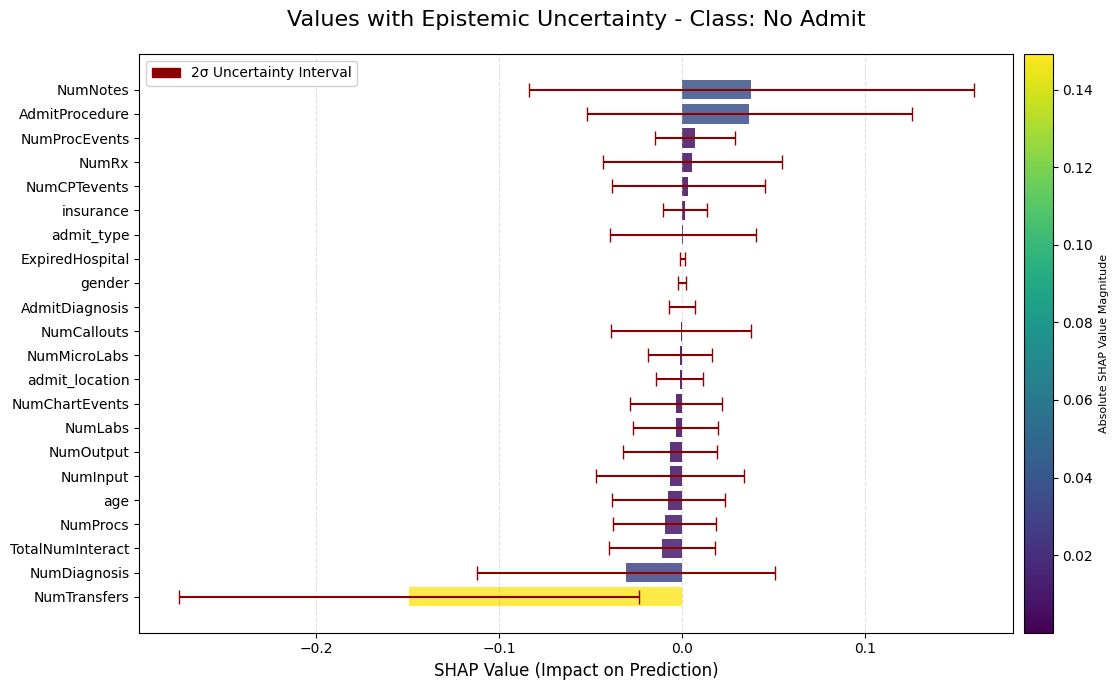

Top 5 indices: [21  7  9 14 18]


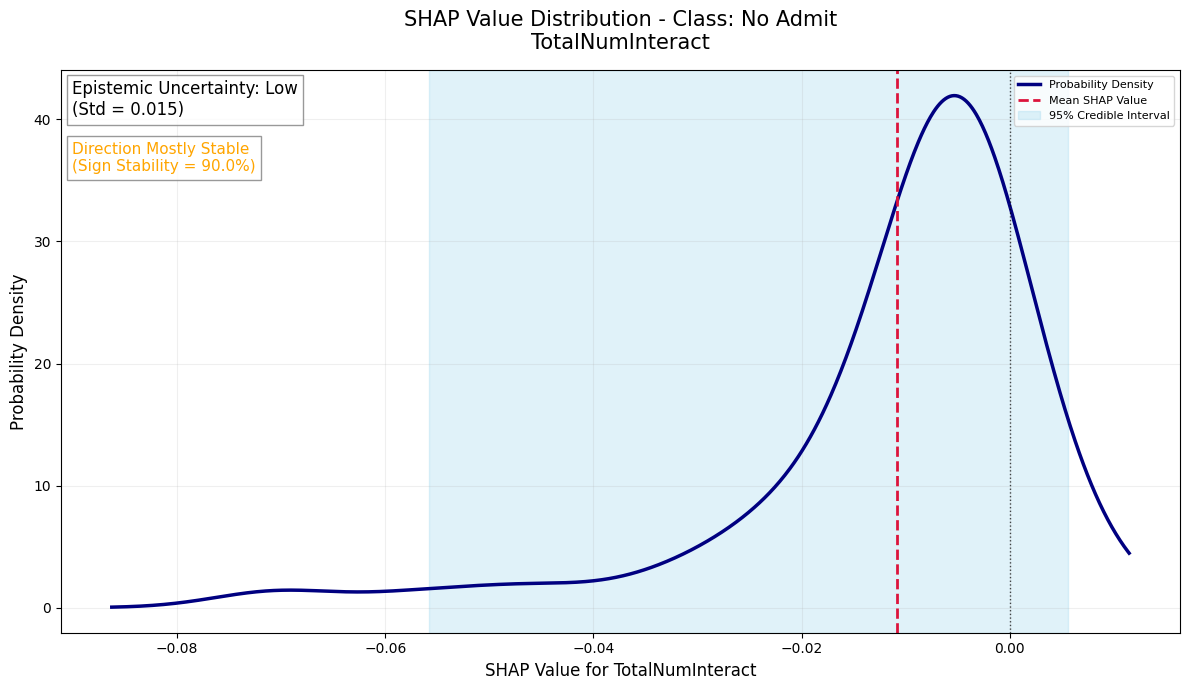

Top 5 indices: [21  7  9 14 18]


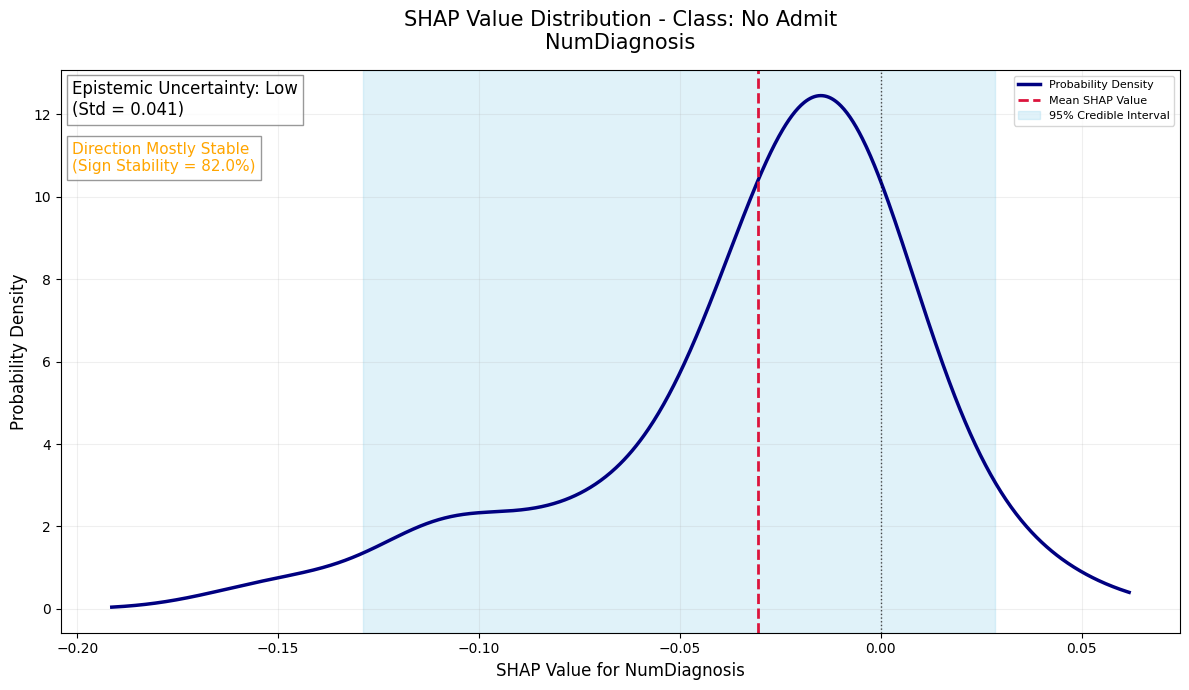

Top 5 indices: [21  7  9 14 18]


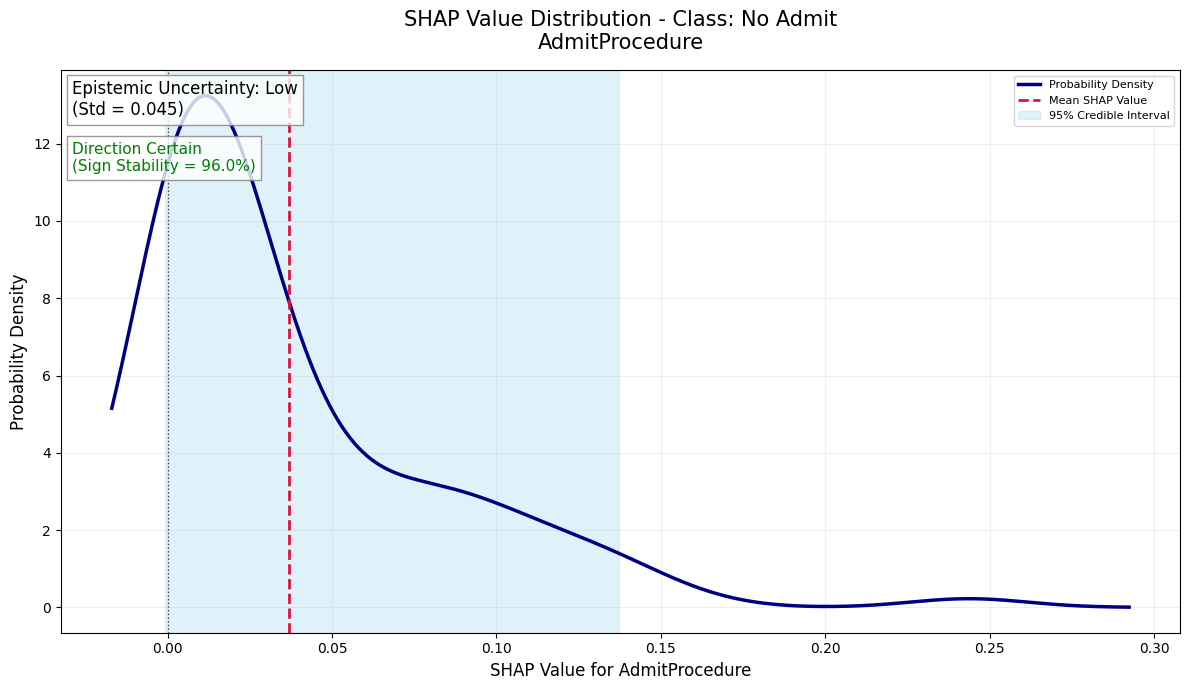

Top 5 indices: [21  7  9 14 18]


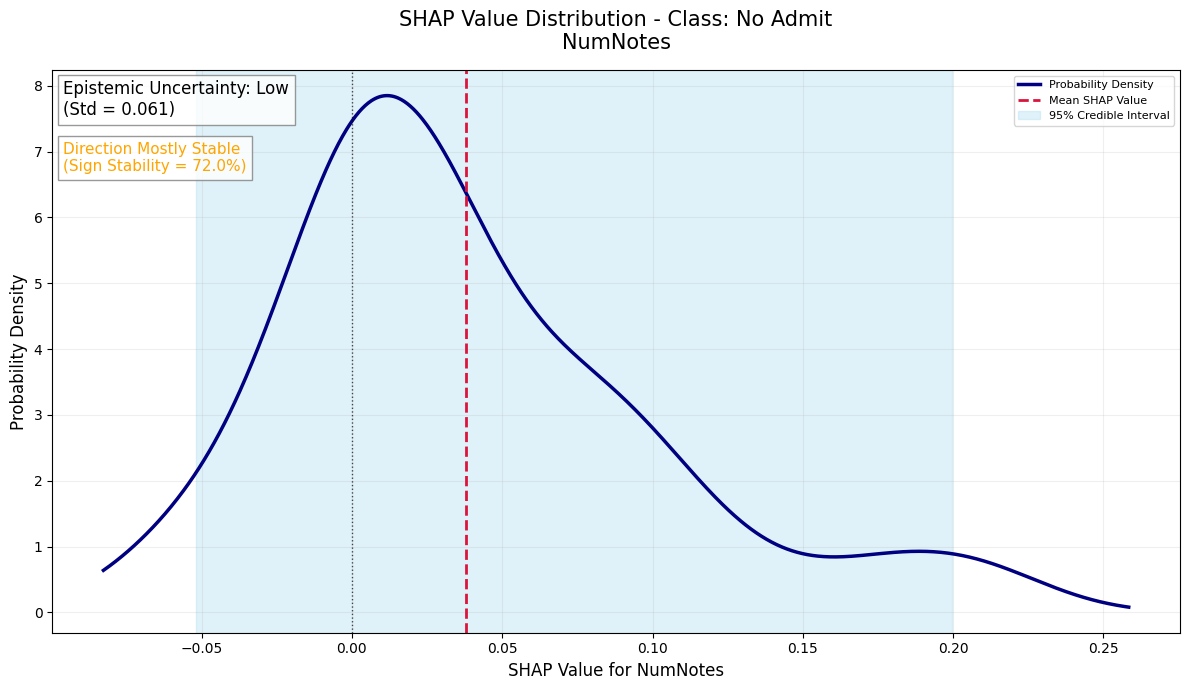

Top 5 indices: [21  7  9 14 18]


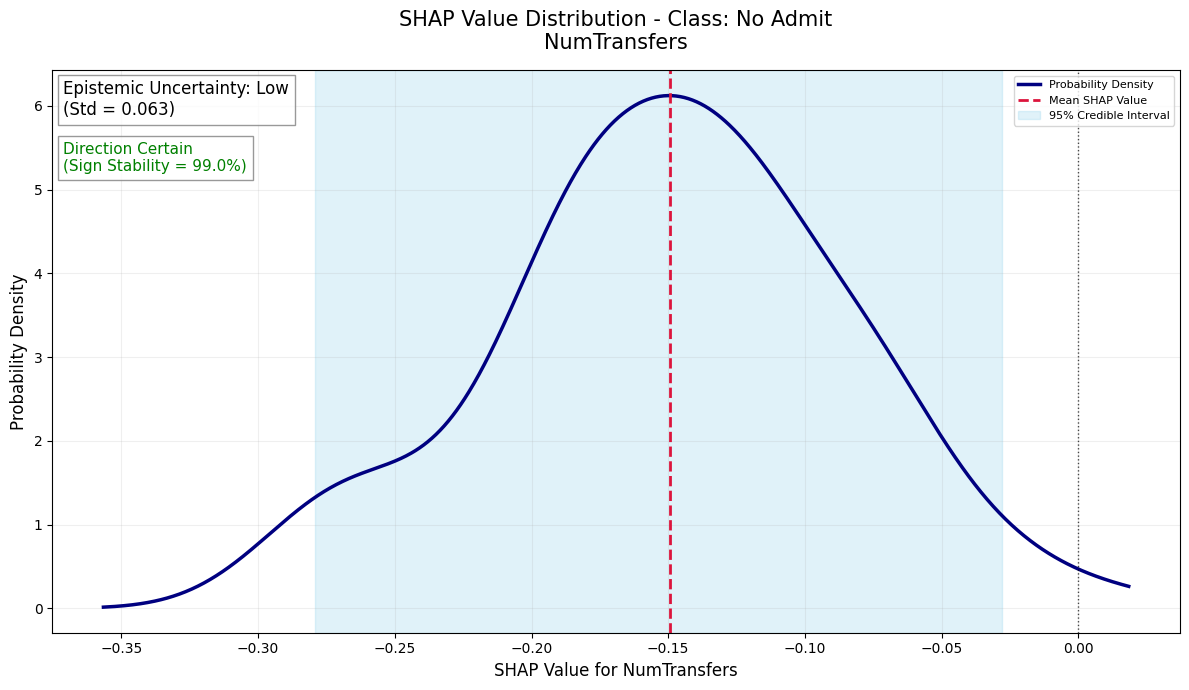

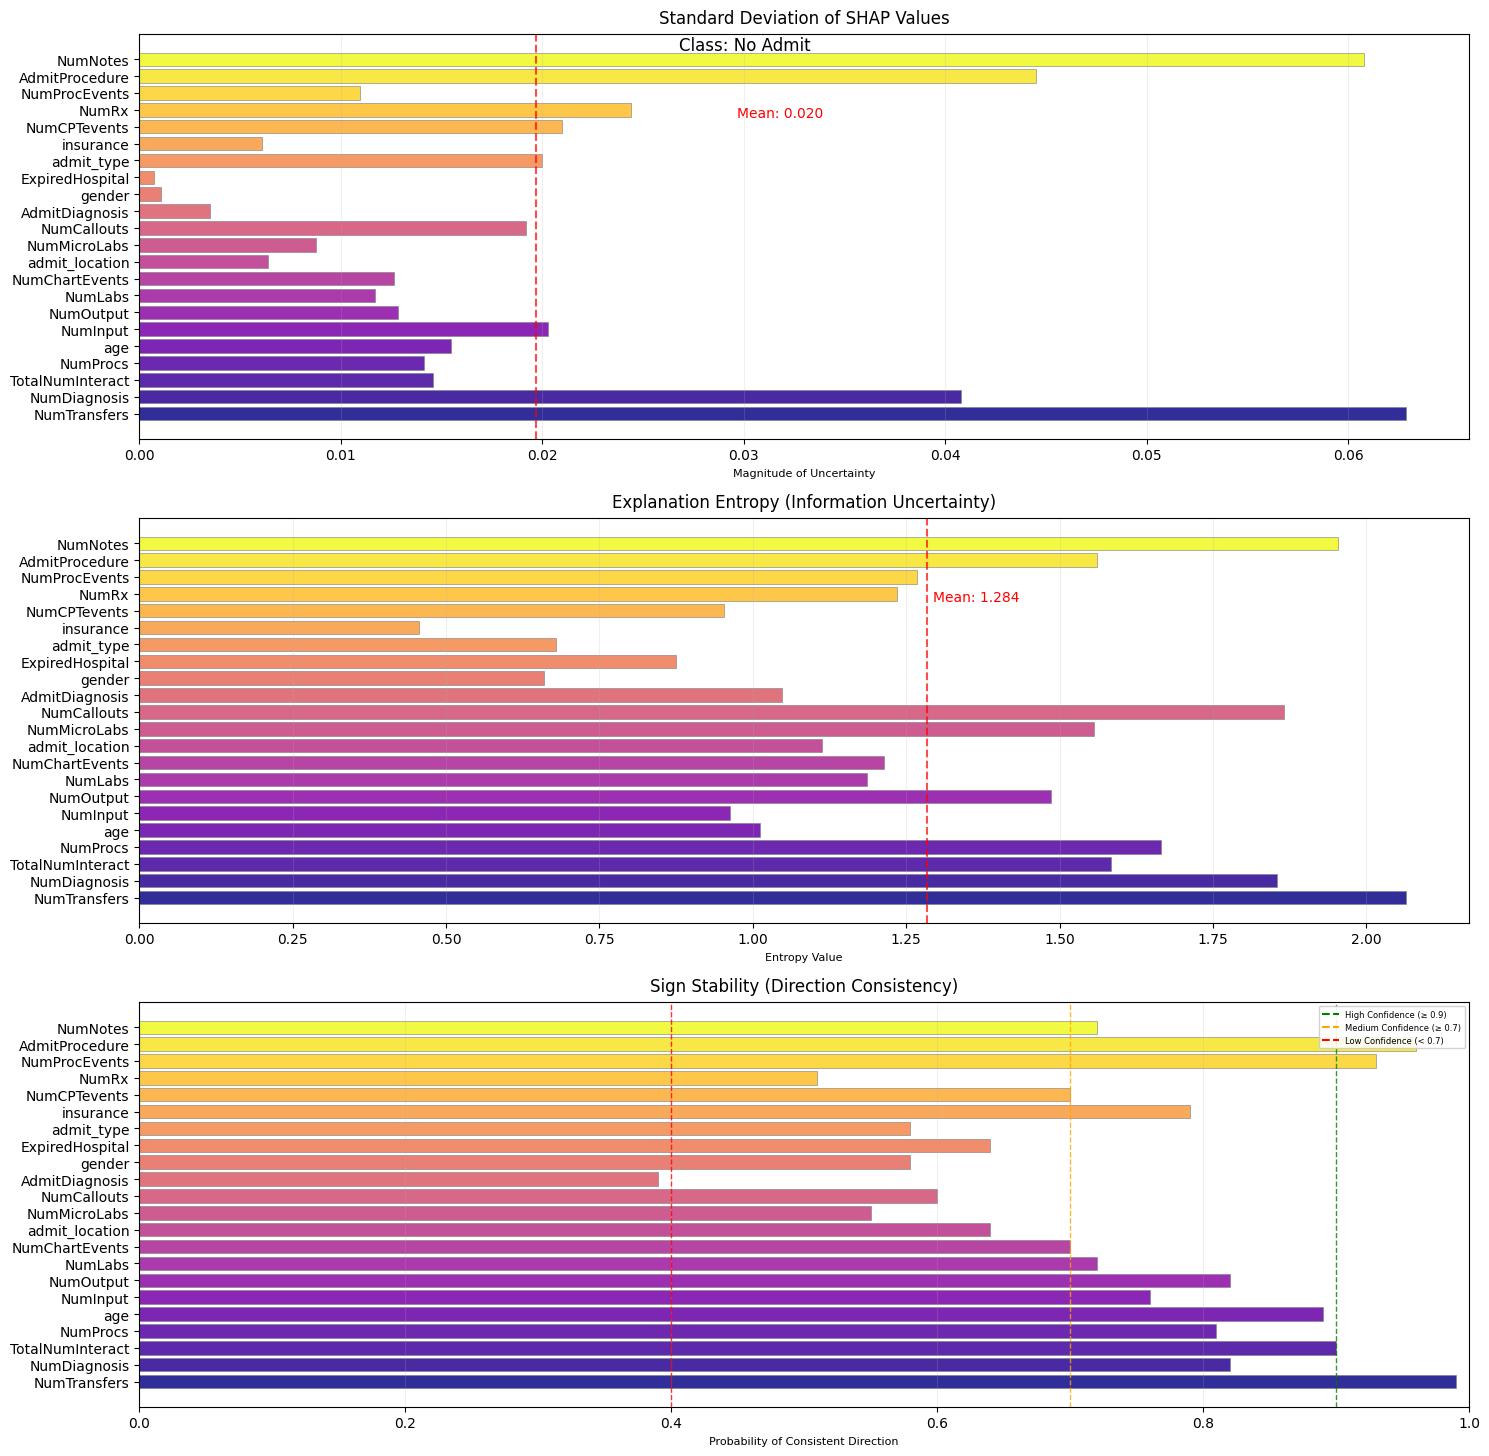


Explaining for class: Very Short Stay


Sampling hypothesis space: 100%|██████████| 100/100 [00:06<00:00, 14.55it/s]


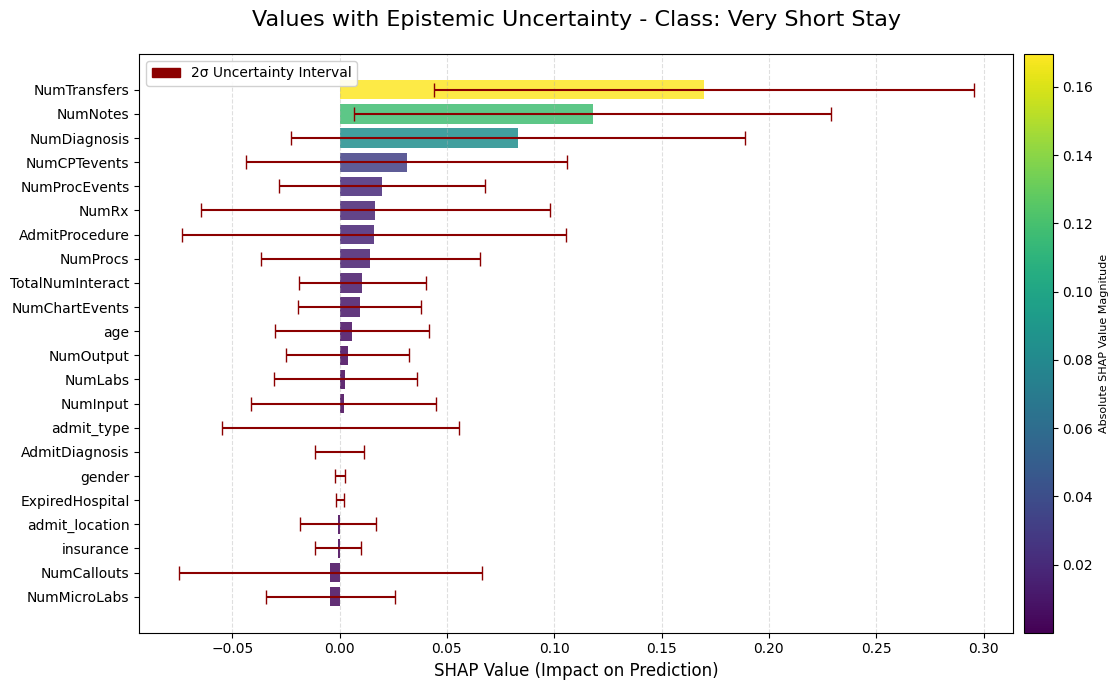

Top 5 indices: [17 10  7 14 18]


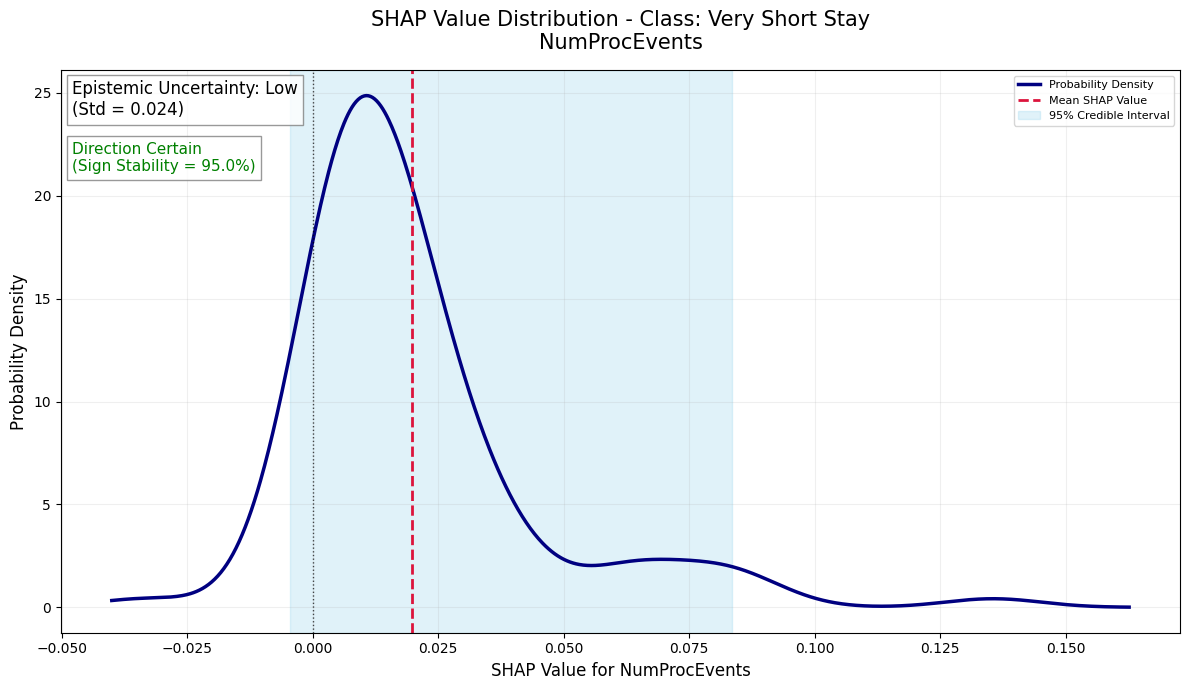

Top 5 indices: [17 10  7 14 18]


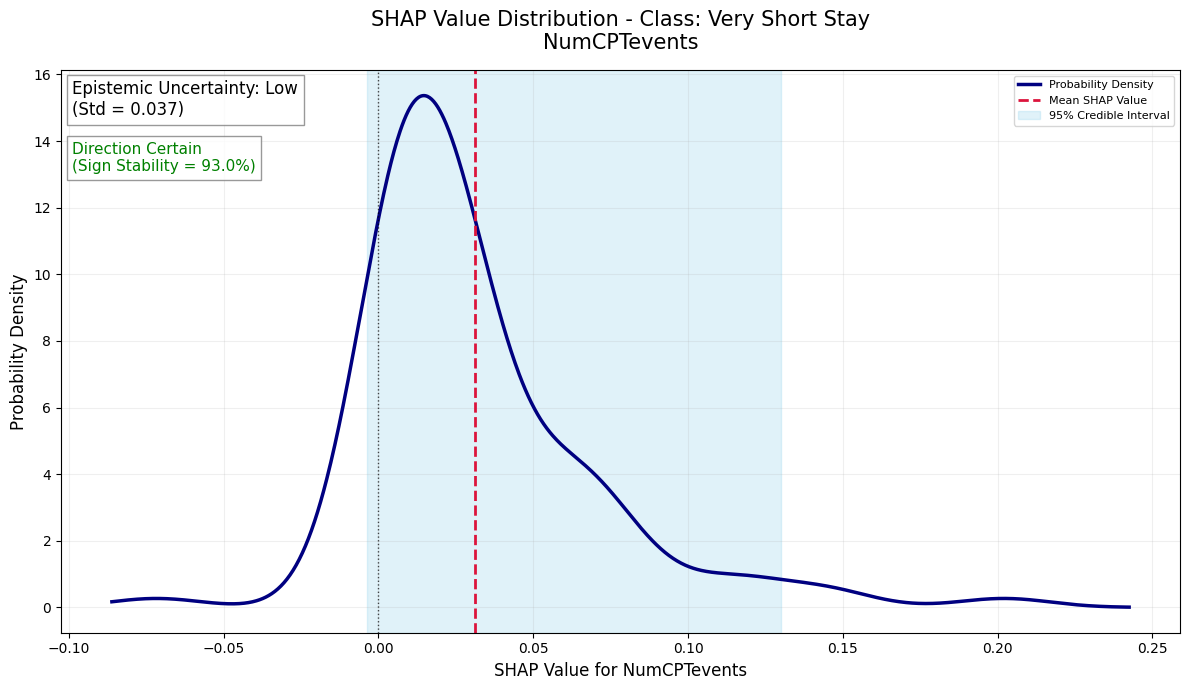

Top 5 indices: [17 10  7 14 18]


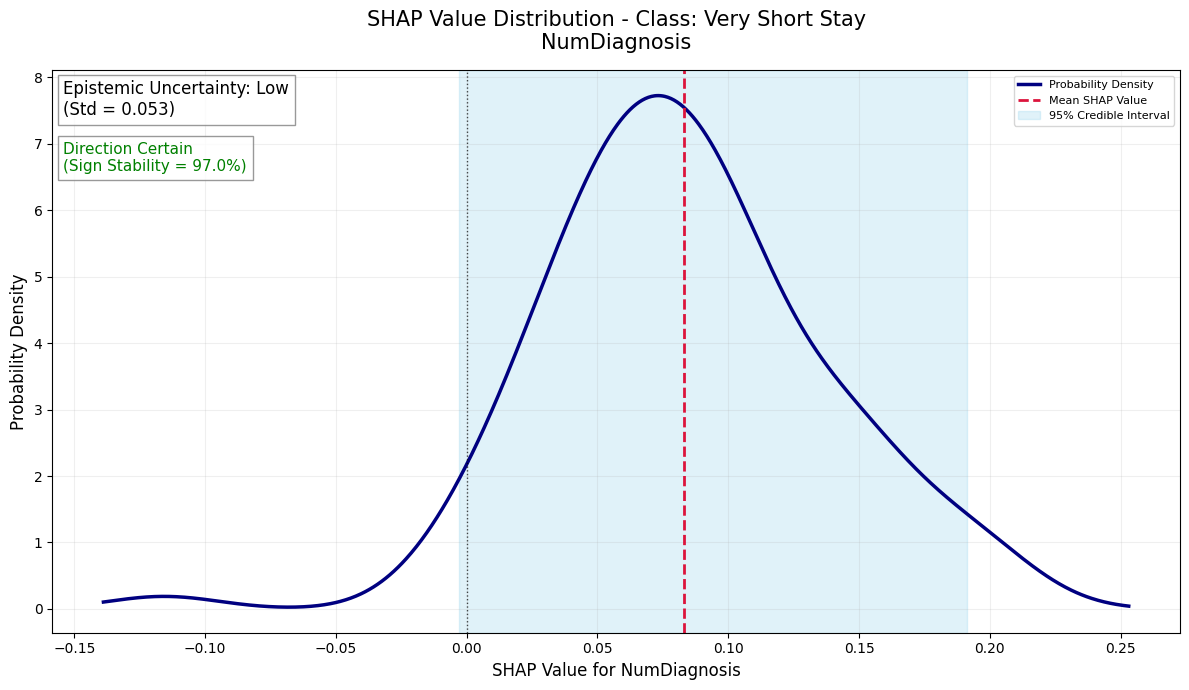

Top 5 indices: [17 10  7 14 18]


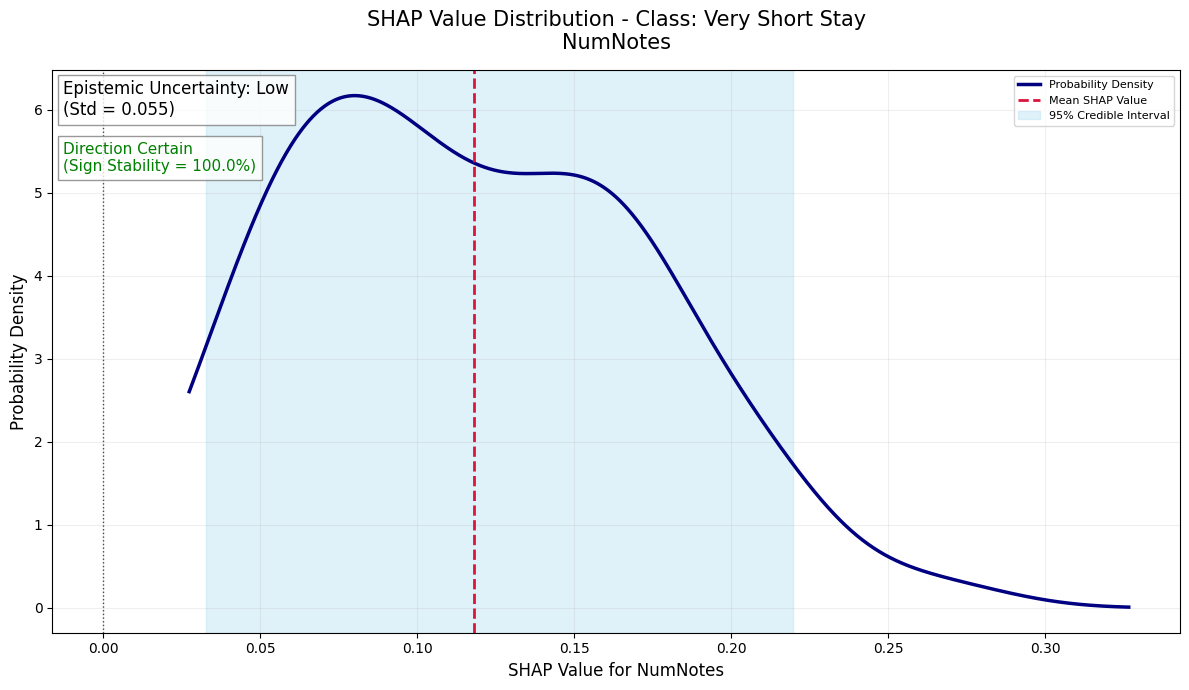

Top 5 indices: [17 10  7 14 18]


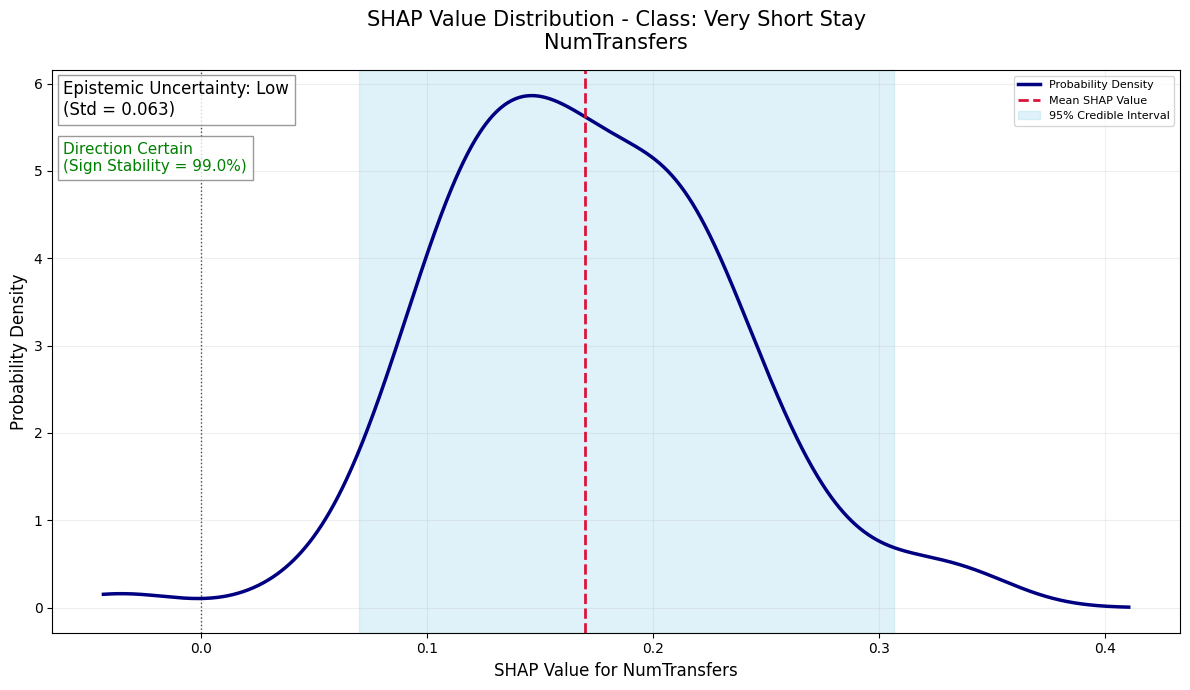

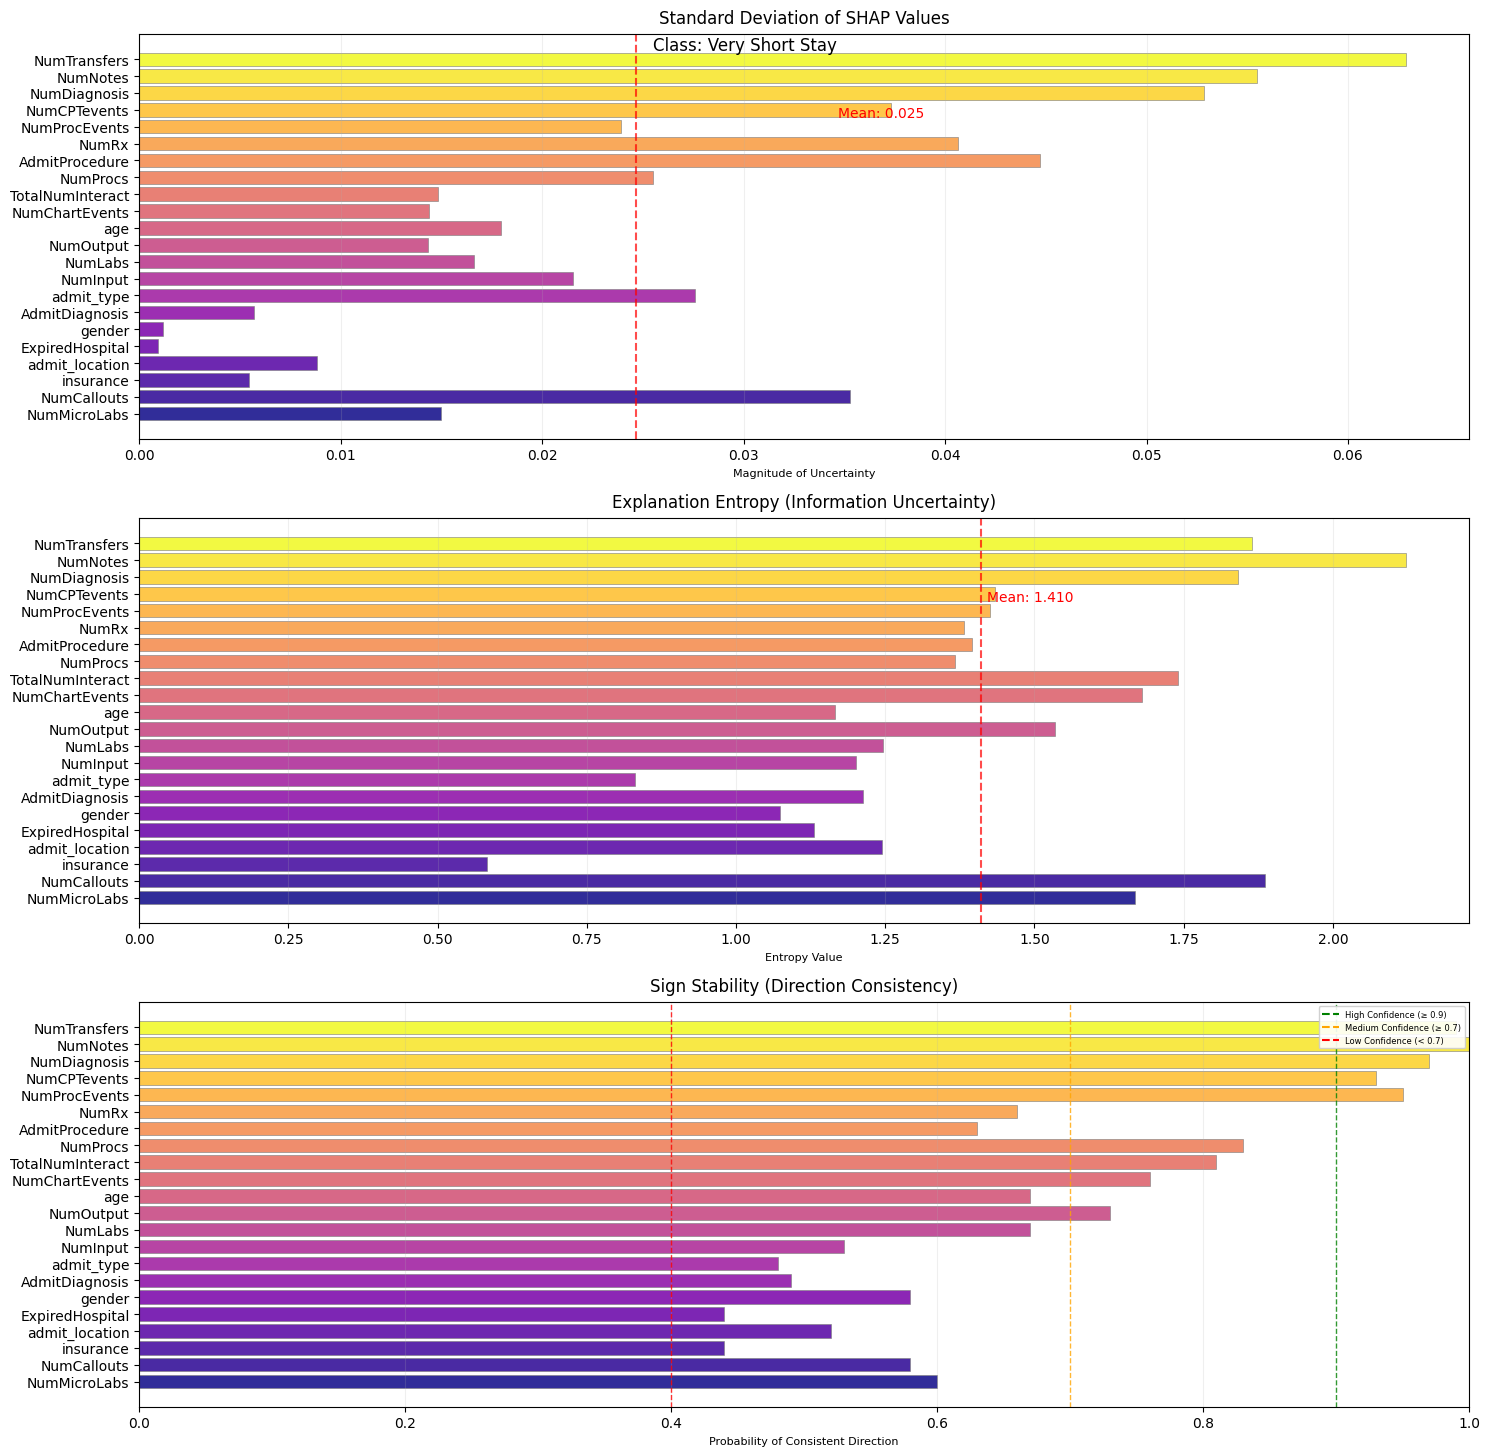


Explaining for class: Short Stay


Sampling hypothesis space: 100%|██████████| 100/100 [00:06<00:00, 14.48it/s]


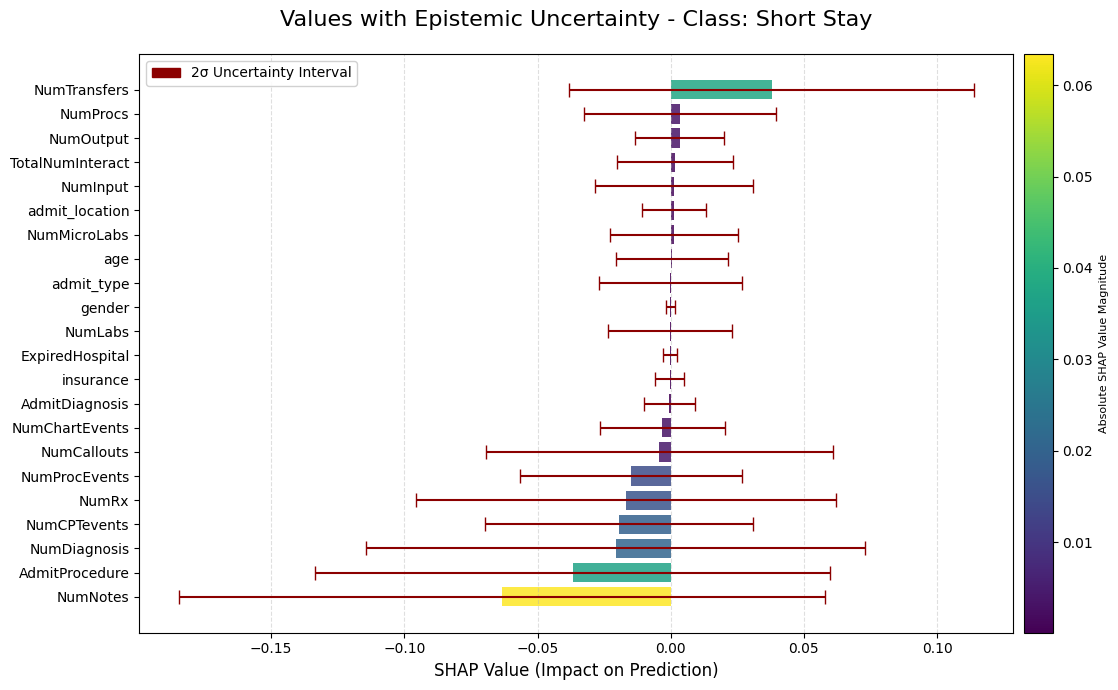

Top 5 indices: [10  7  9 18 14]


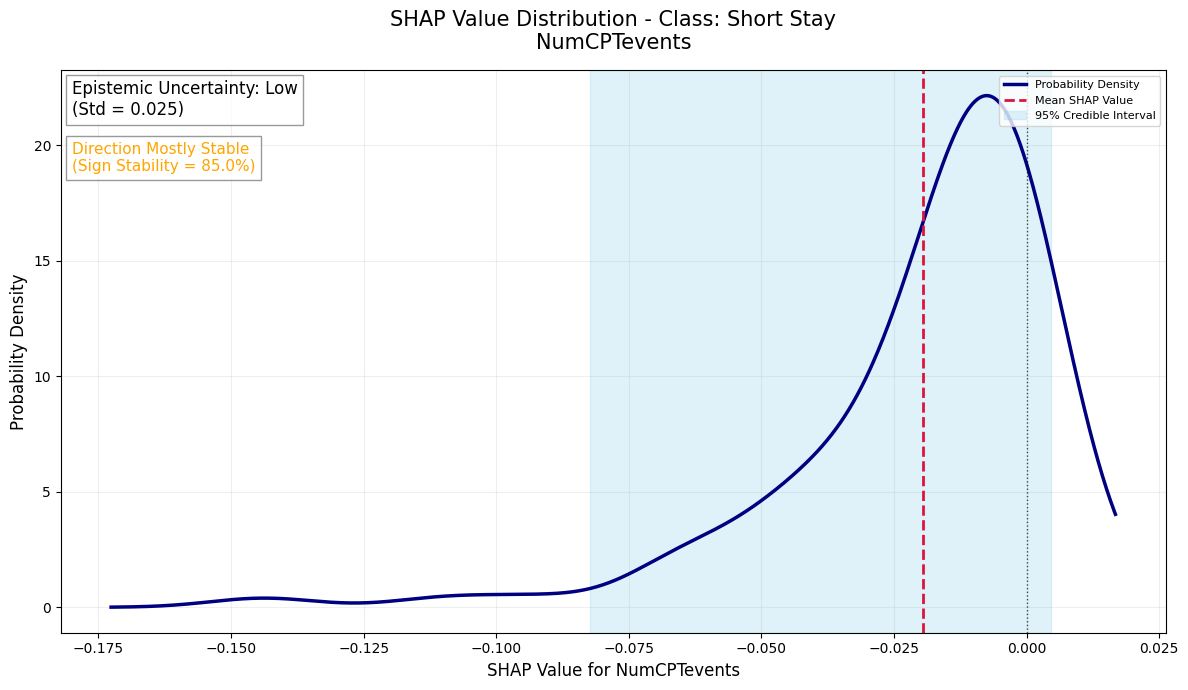

Top 5 indices: [10  7  9 18 14]


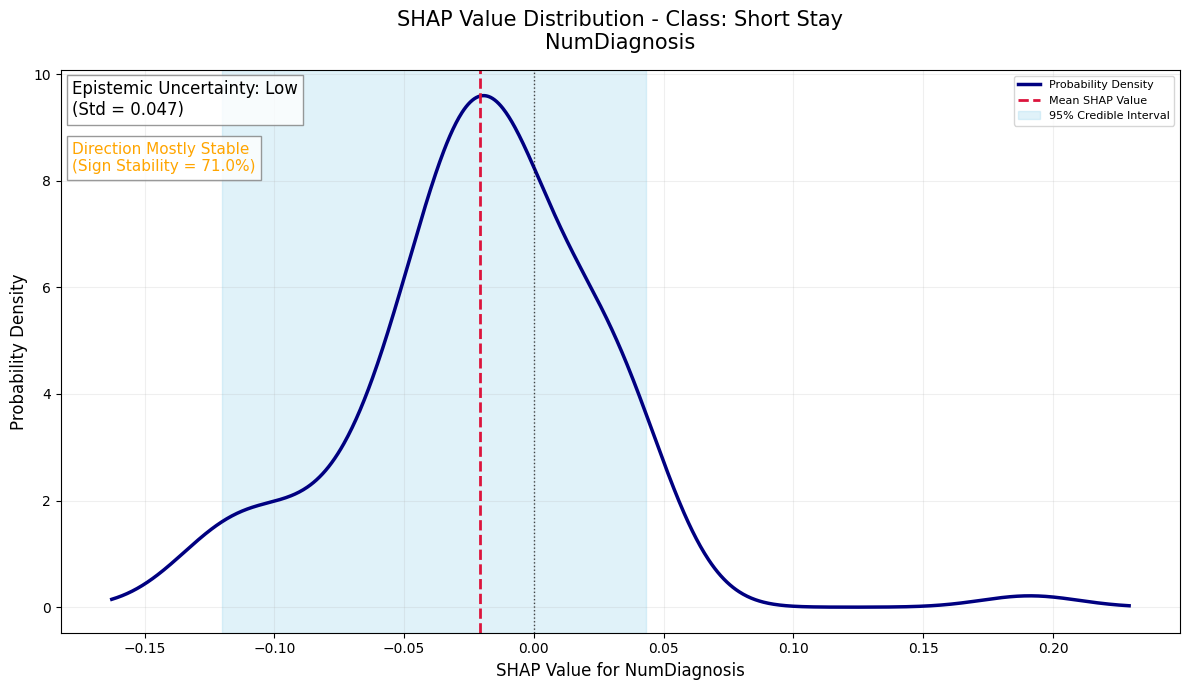

Top 5 indices: [10  7  9 18 14]


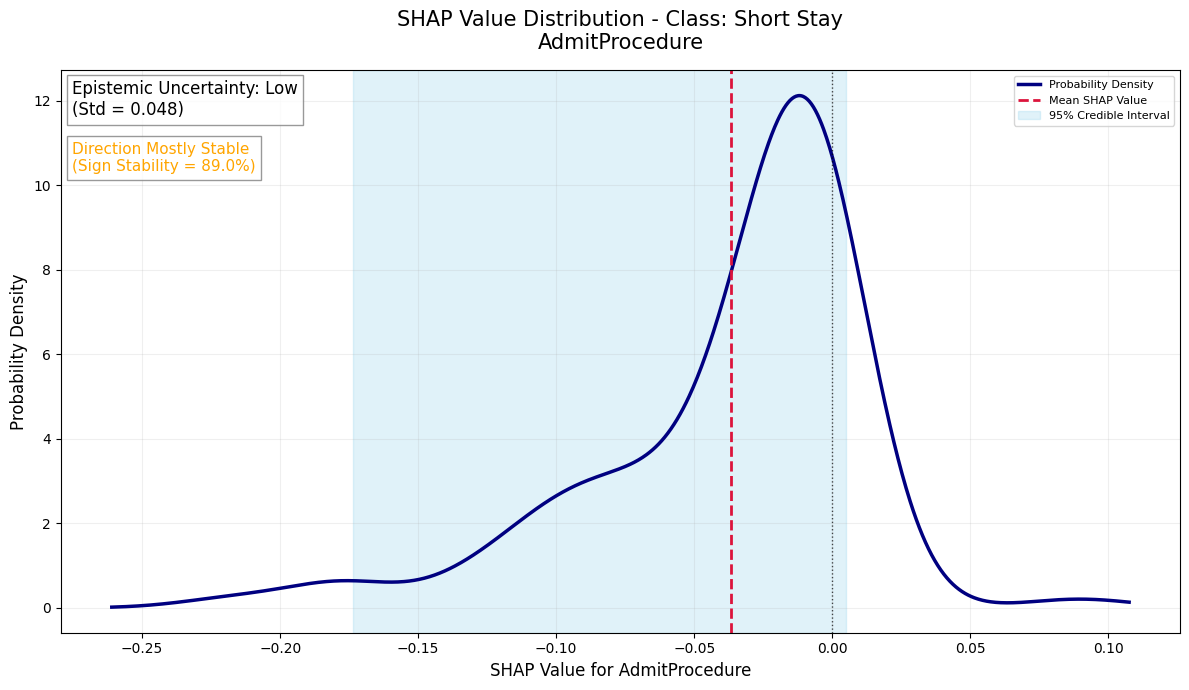

Top 5 indices: [10  7  9 18 14]


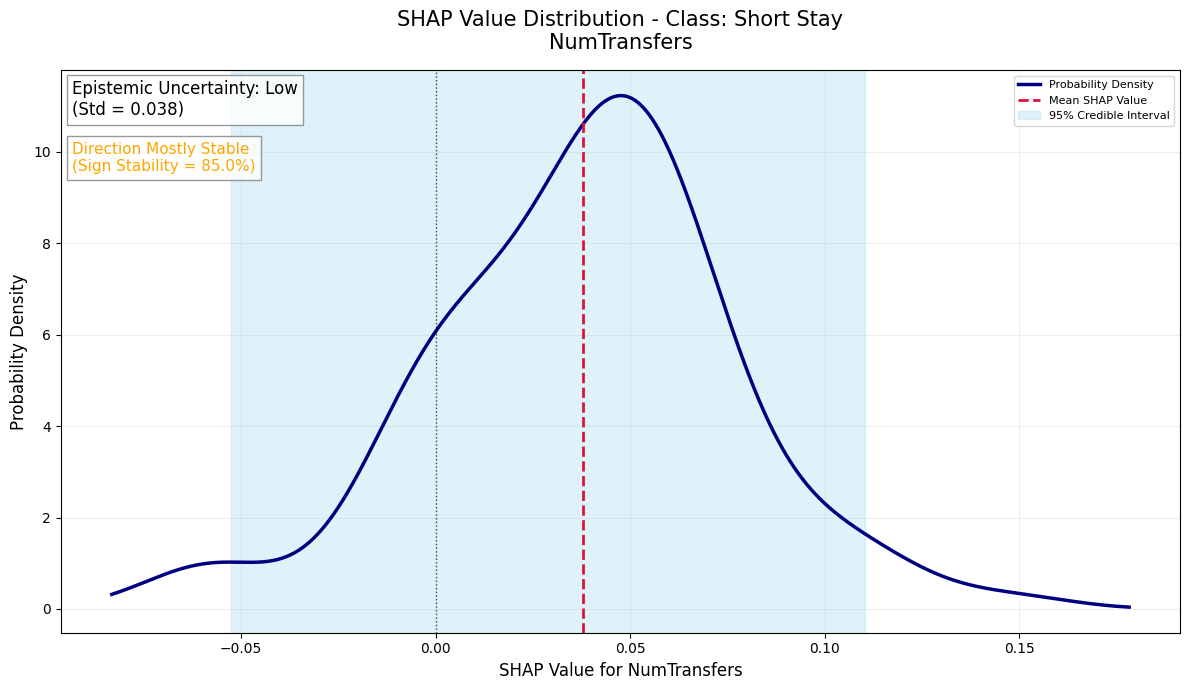

Top 5 indices: [10  7  9 18 14]


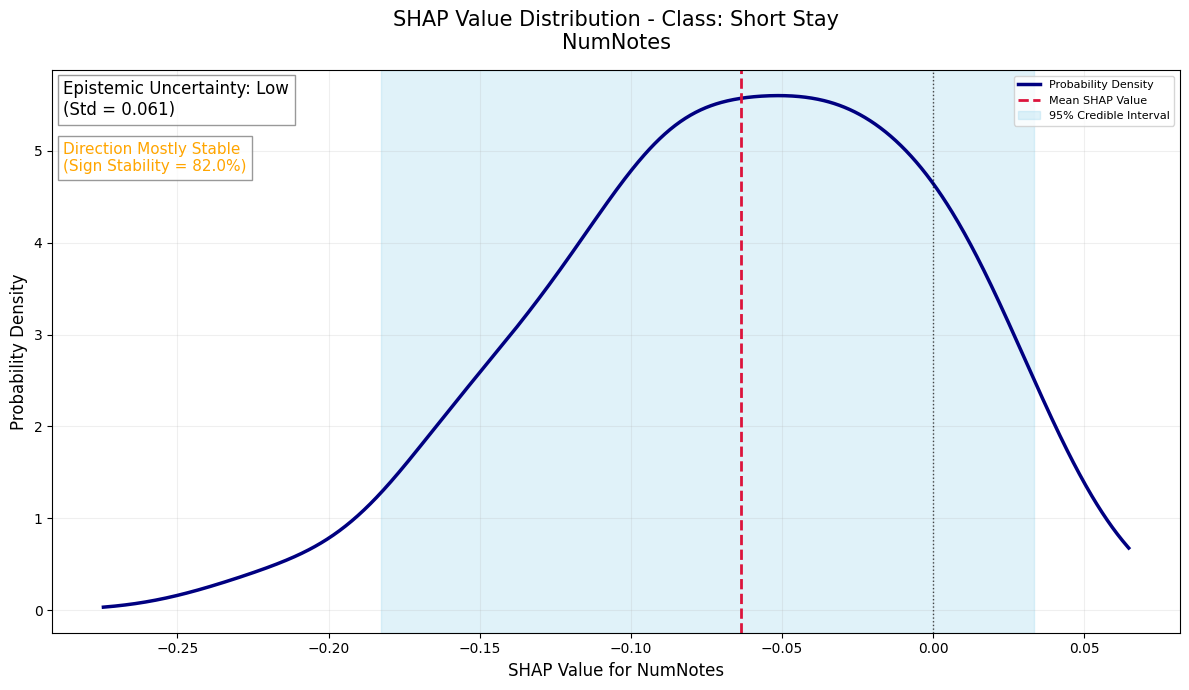

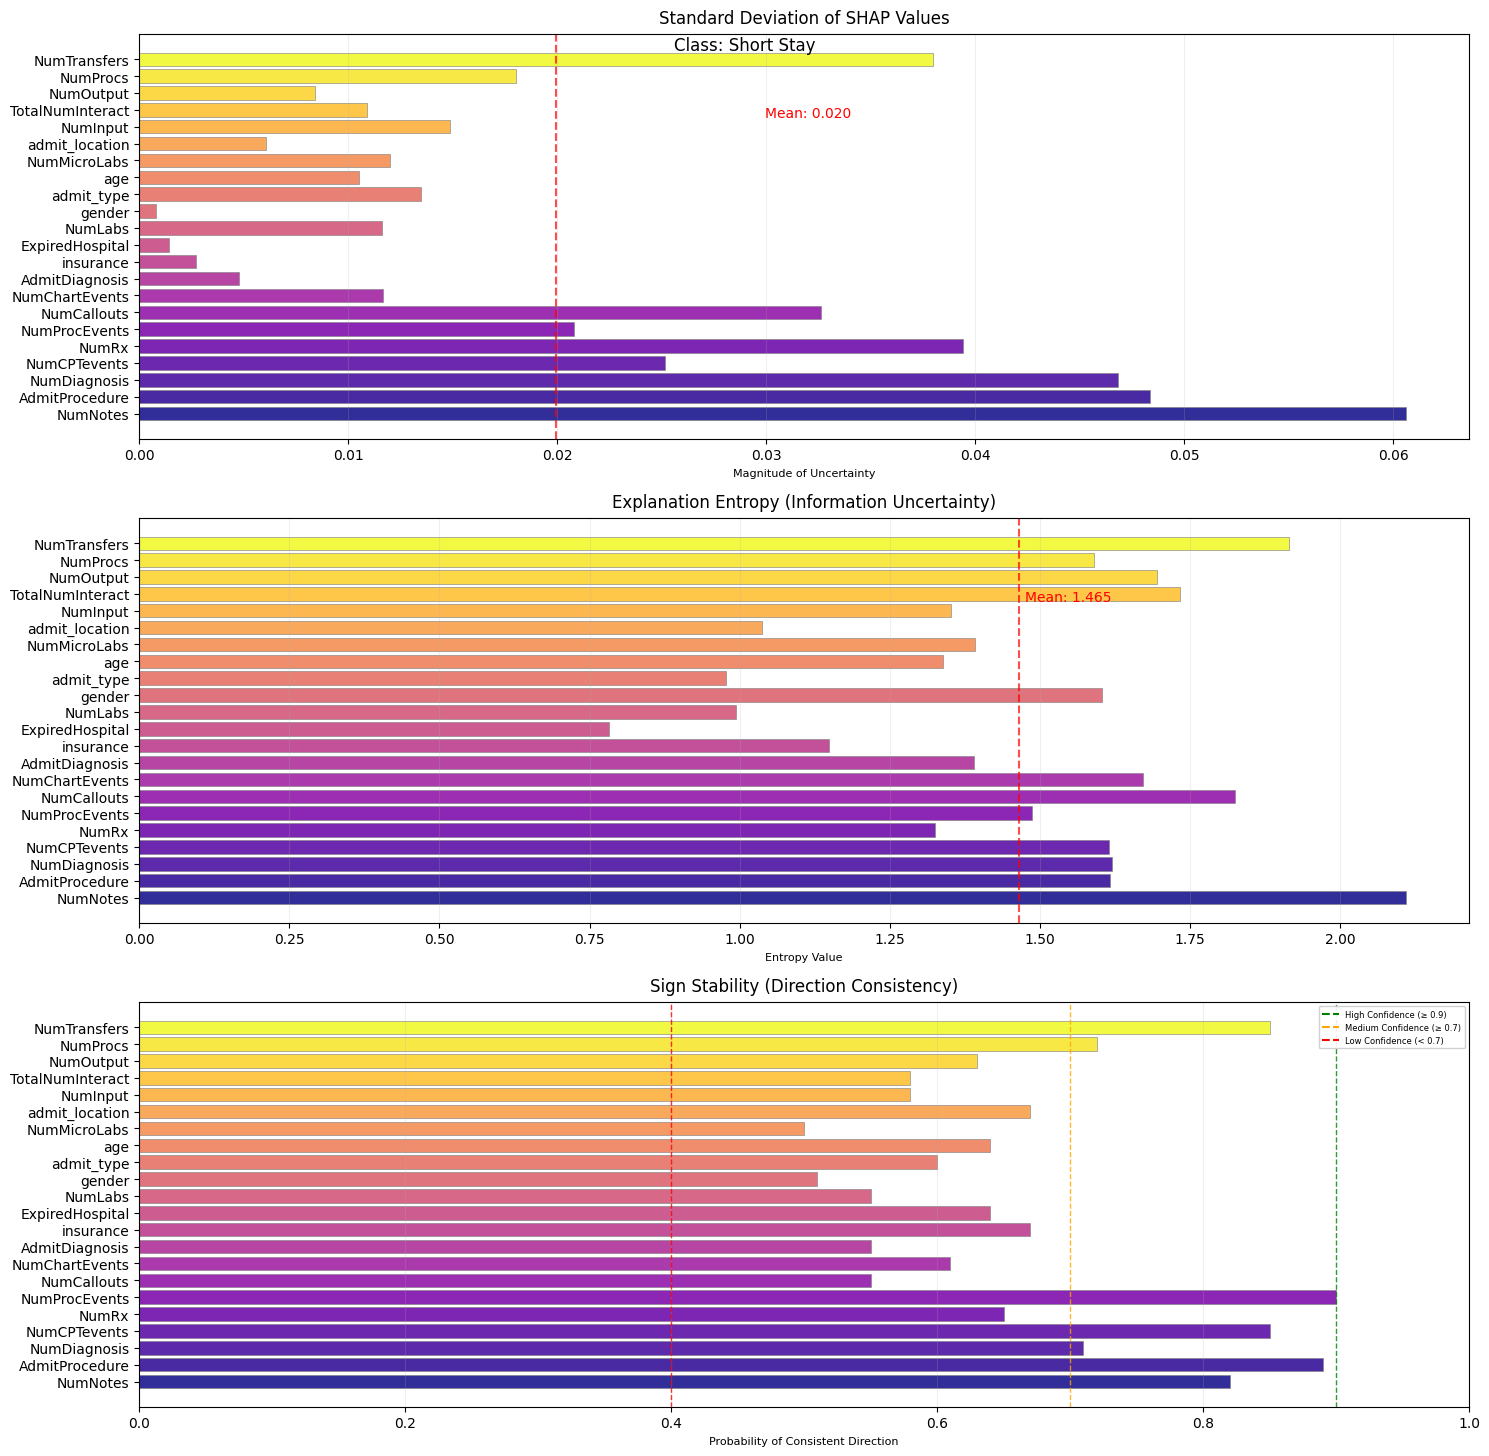


Explaining for class: Long Stay


Sampling hypothesis space: 100%|██████████| 100/100 [00:06<00:00, 14.46it/s]


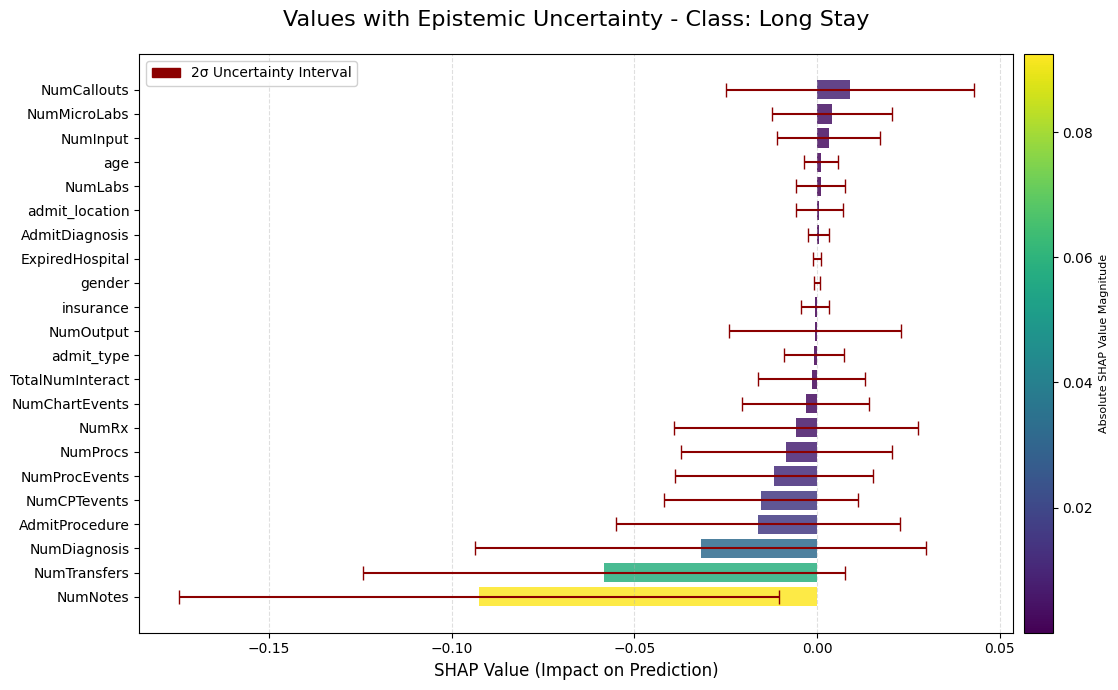

Top 5 indices: [10  9  7 18 14]


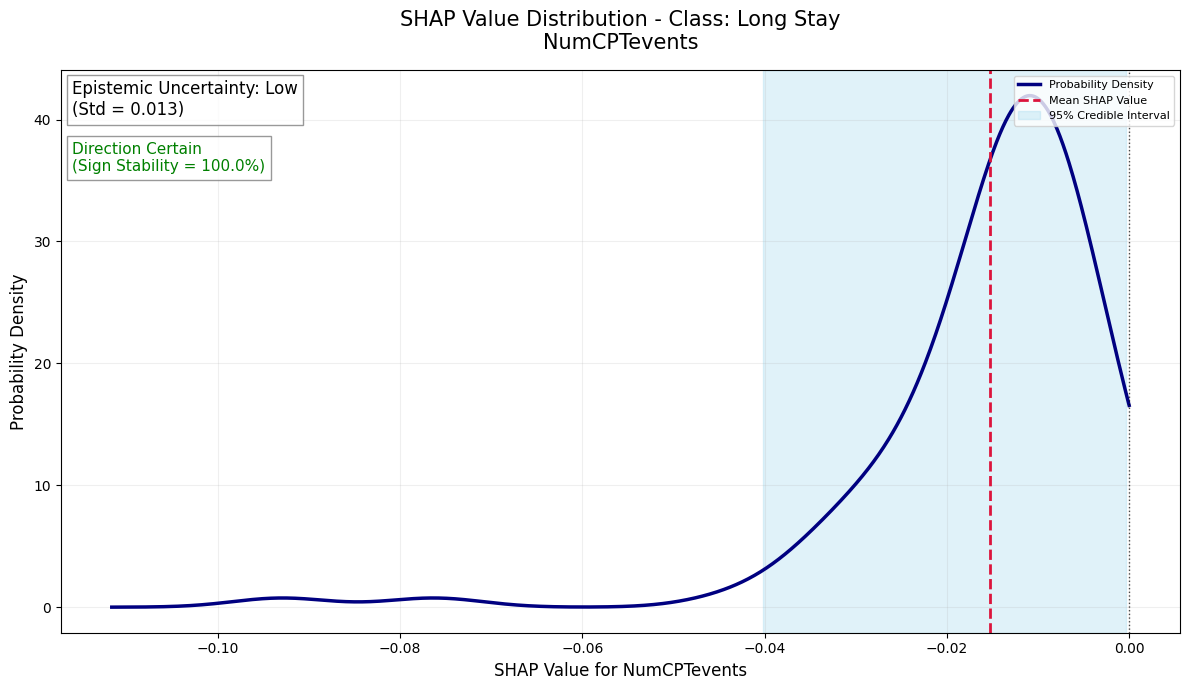

Top 5 indices: [10  9  7 18 14]


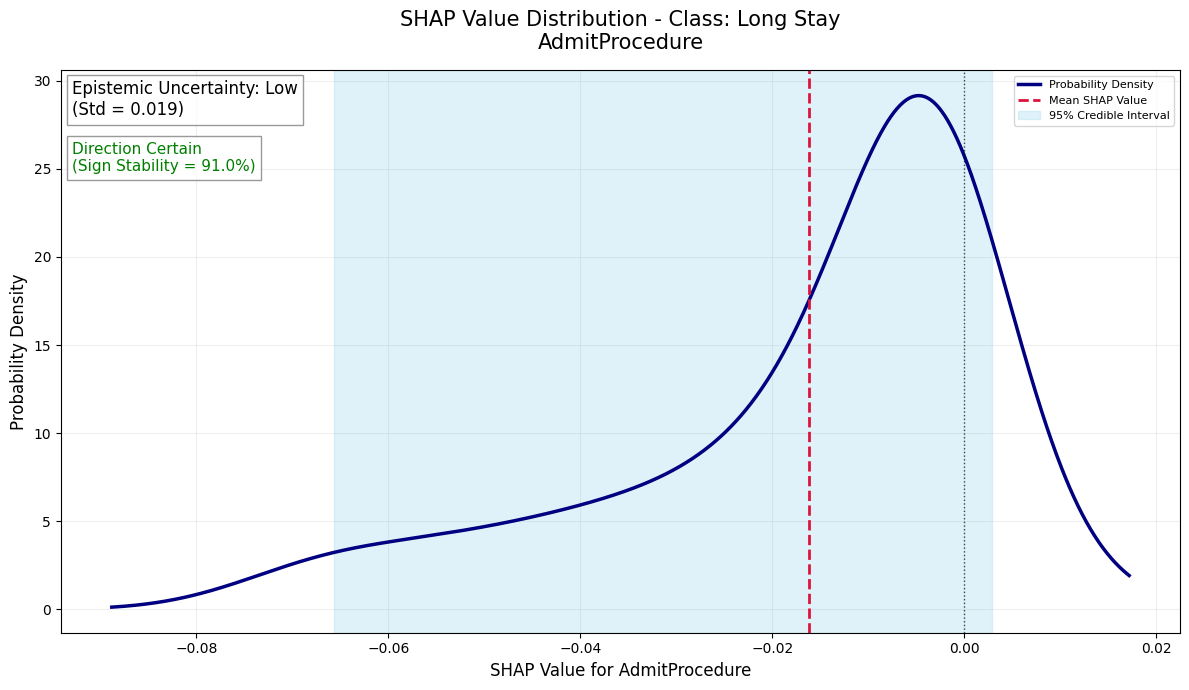

Top 5 indices: [10  9  7 18 14]


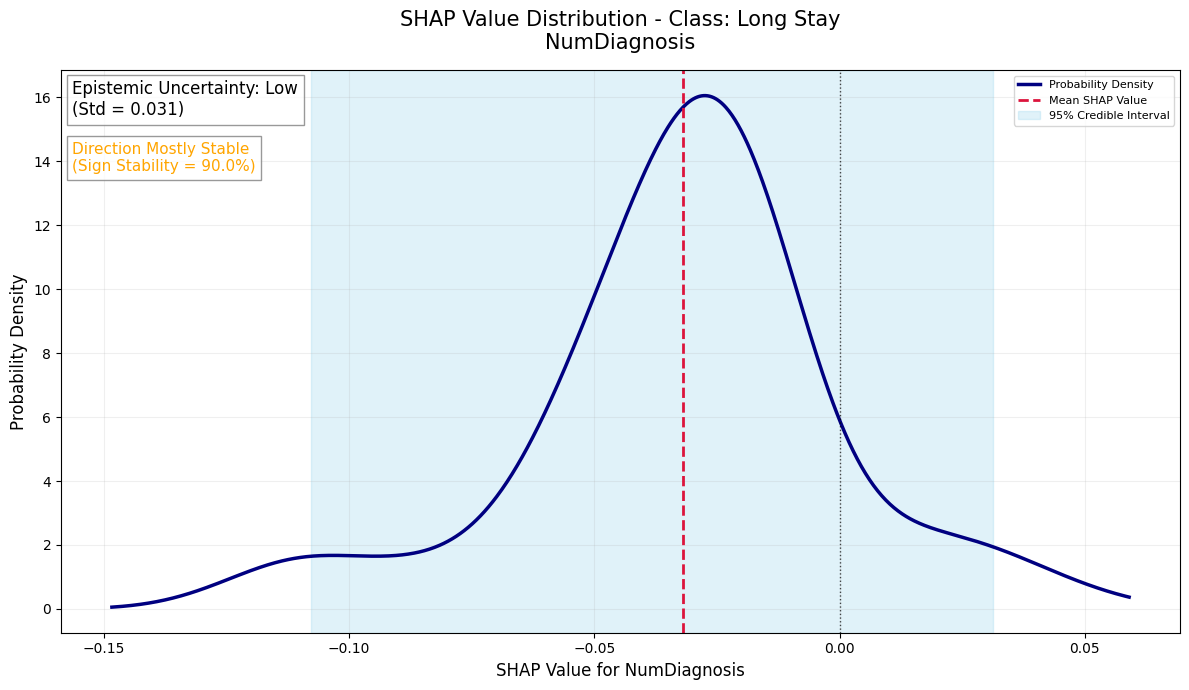

Top 5 indices: [10  9  7 18 14]


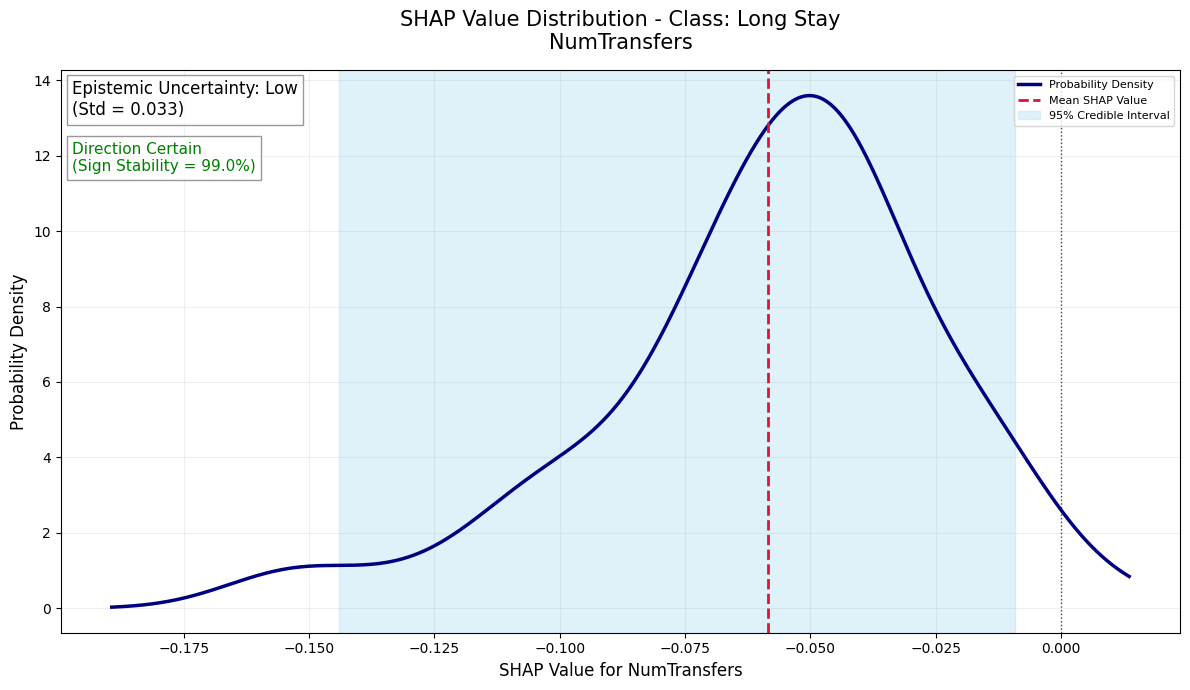

Top 5 indices: [10  9  7 18 14]


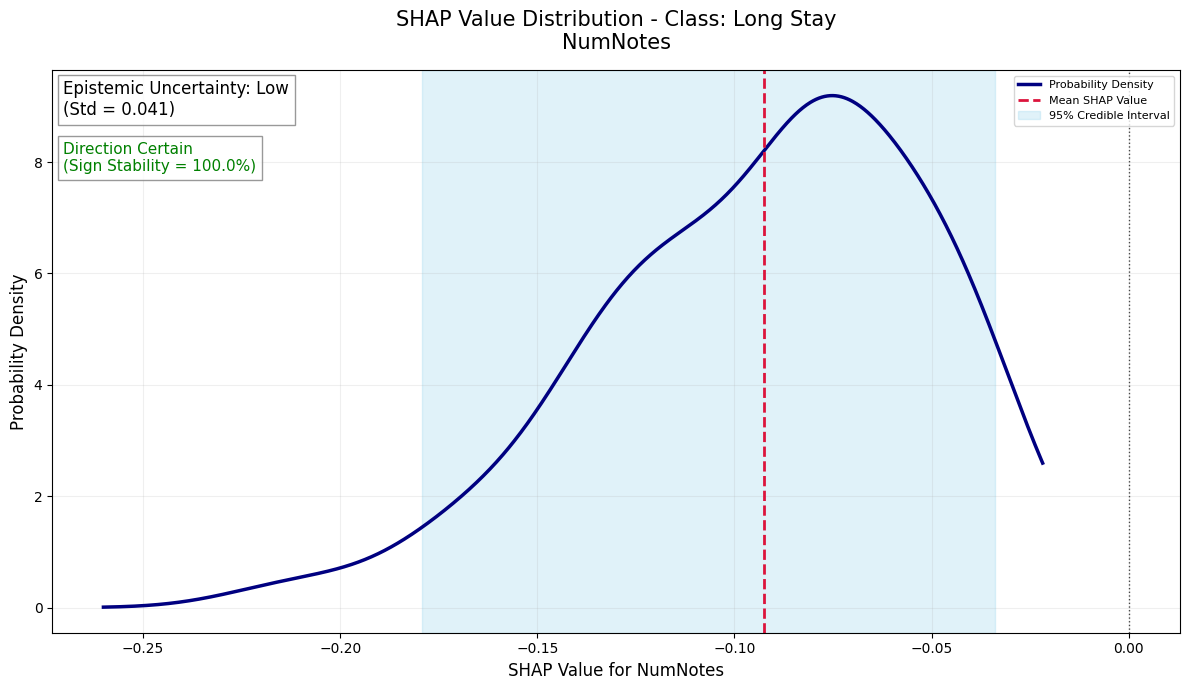

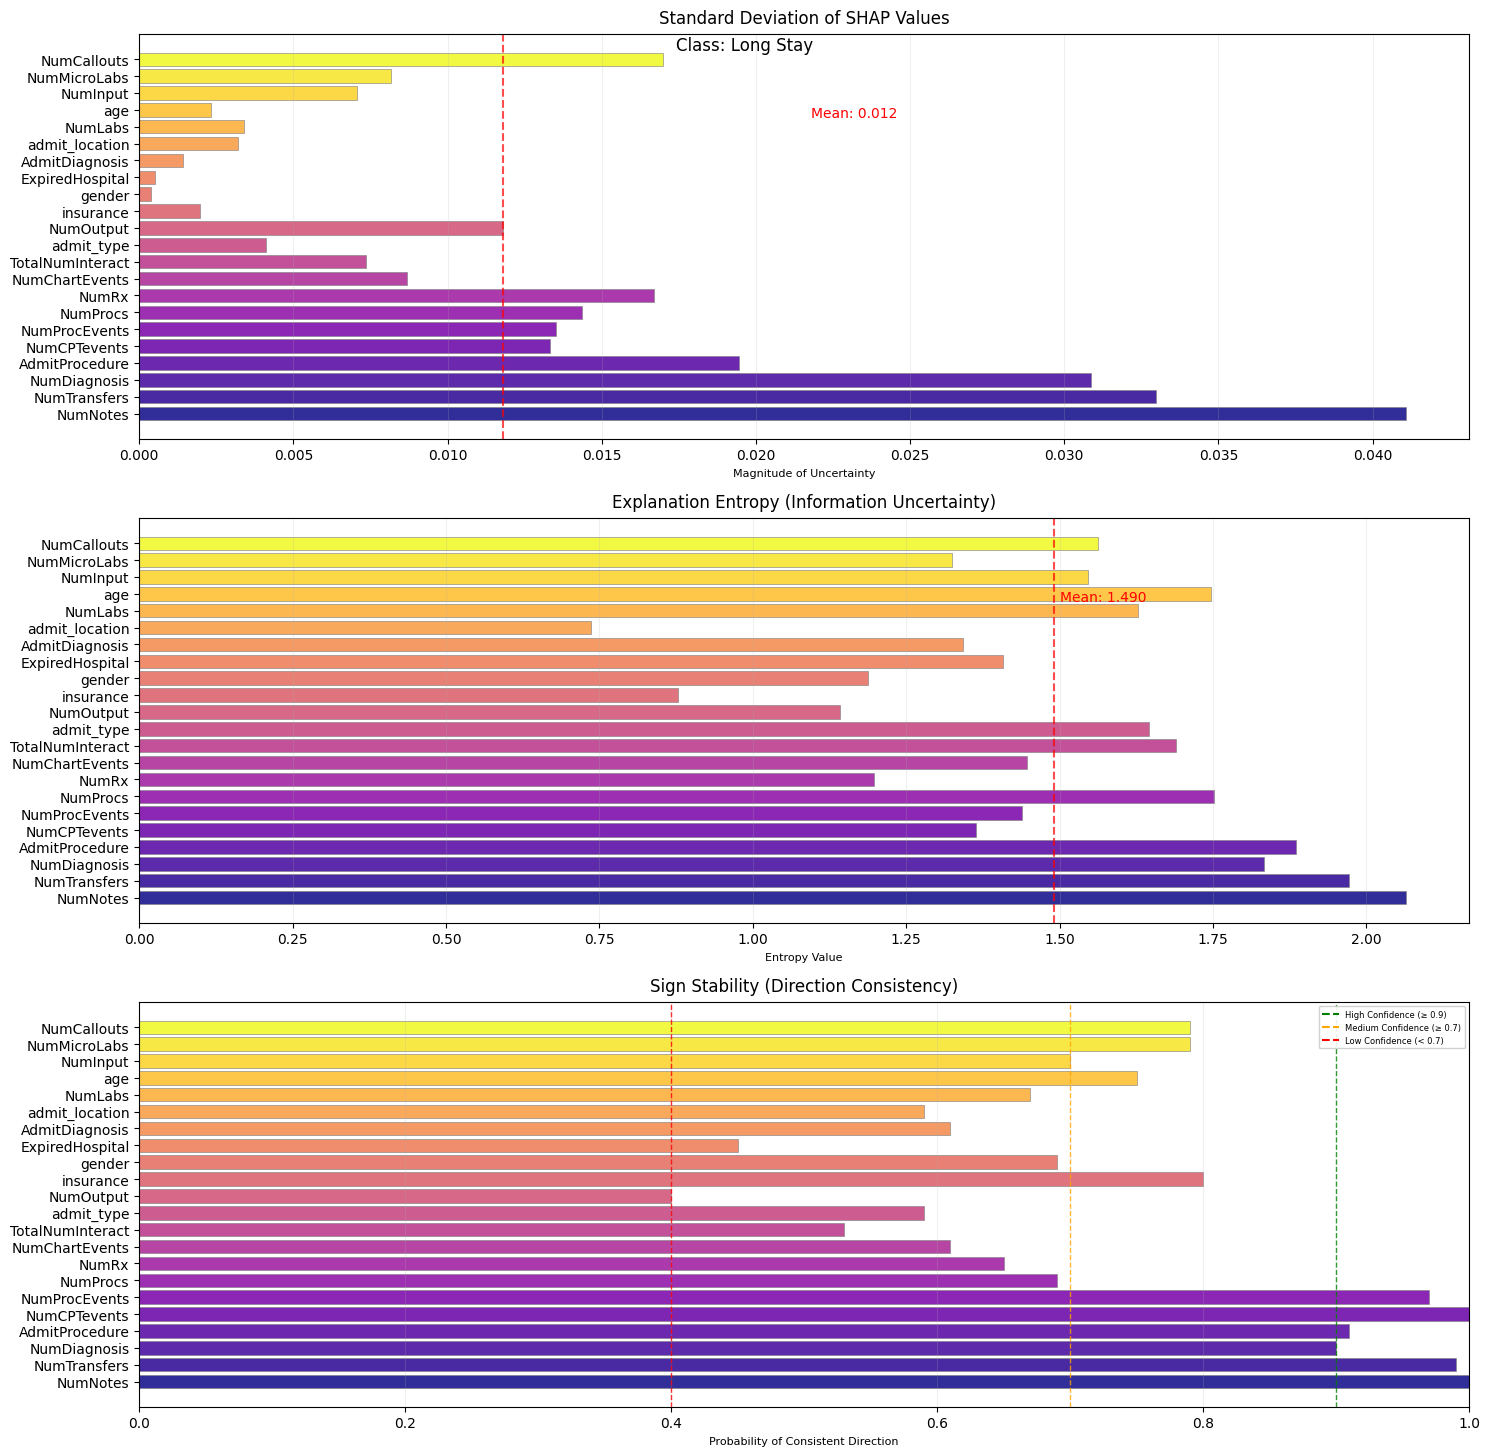

In [22]:
from UQEnTree import ExplainerClassification

import numpy as np


explainer = ExplainerClassification(model, X_train, y_train, beta=5.0, random_state=42)

# Explain first instance for each class
instance = X_test[0:1]

for class_idx, class_name in enumerate(class_names):
    print(f"\nExplaining for class: {class_name}")
    results = explainer.explain(instance, class_idx=class_idx,  n_samples=100, alpha=0.5)
       # Plot results
    explainer.plot_uncertainty_bars(
        results, 
        feature_names,
        class_name=class_name
    )
    
    
    # # Plot distribution for most important feature
    # most_important_feature = np.argmax(np.abs(results['mean']))
    # print("The most important feature is :", most_important_feature)
    top5_indices = np.argsort(np.abs(results["mean"]))[-5:]
    for i in top5_indices:

        print("Top 5 indices:", top5_indices)
        explainer.plot_uncertainty_distribution(
            results,
            feature_names,
            i,
            class_name=class_name
        )
    
    explainer.plot_uncertainty_comparison(
        results,
        feature_names,
        class_name=class_name
    )
